In [1]:
'''
Notebook for assessing and documenting calibration results
'''

__author__ =  'Christian Dewey'
__date__   =  '29 December 2025'
__version__ = '0.1.0'

import sys
from pathlib import Path

from h5py import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pflotranutils.h5_output.calc.cross_section import CrossSection 

sys.path.insert(0, str(Path.cwd().parent))
from src.processing.pflotran import PflotranProcessor

sys.path.insert(0, str(Path.cwd().parent.parent / 'results')) # Add results directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'model-output')) # Add model-output directory to path


#####
##### SET THESE PARAMS
#####

NOTE="added surface passivation param to Fe reduction rxns"
RUN_ID = 'manual_cal010'

#####
#####
#####

OBS_PATH = str(Path.cwd().parent / 'data/observational')
RUN_PATH = str(Path.cwd()/ f'run_{RUN_ID}')

SPIN_FILE = Path(f'pflotran-mcp19_{RUN_ID}_spin.h5')
TRANS_FILE = Path(f'pflotran-mcp19_{RUN_ID}.h5')

chem_obs = pd.read_csv(OBS_PATH + "/porewater/mc_2019_porewater.csv", parse_dates=['Date'])

components = [
    'Total_HCO3- [M]',
    'Total_SO4-- [M]',
    'Total_Ca++ [M]',
    'Total_Fe++ [M]',
    'Total_NO3- [M]',
    'Total_Tracer [M]',
    'Free_O2(aq) [M]',
    'pH'
]

min value for Material_ID: 0.000E+00
max value for Material_ID: 2.000E+00


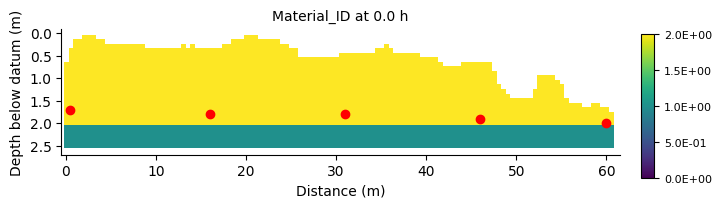

min value for Total_Fe++ [M]: 0.000E+00
max value for Total_Fe++ [M]: 1.492E-04


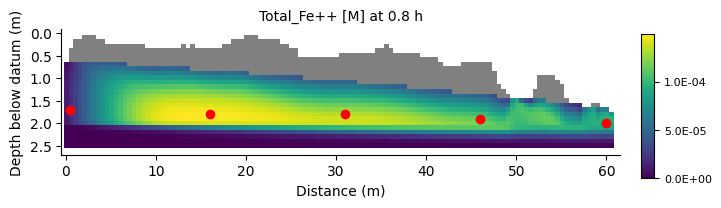

Saved → /Users/christiandewey/Code/dewey-etal_meanders/calibration/run_manual_cal010/manual_cal010_spin_timeseries.png


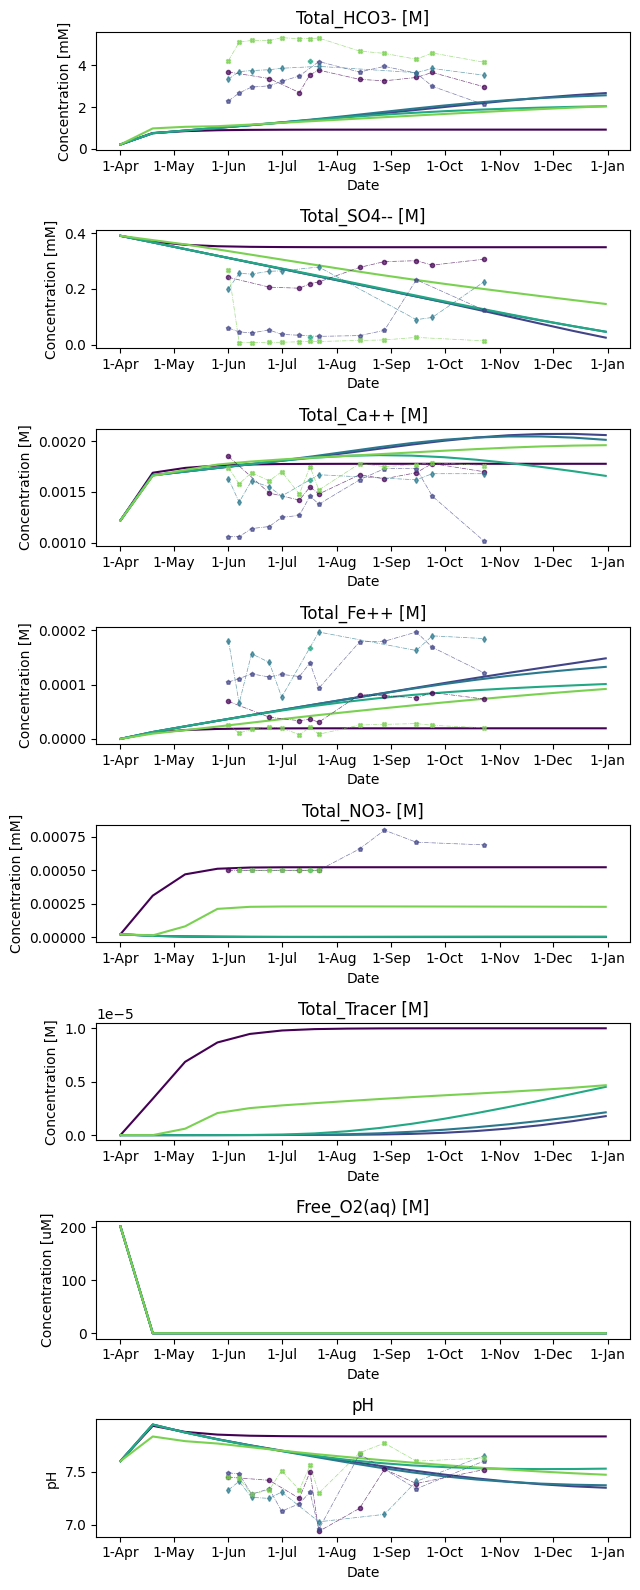

In [2]:
#####
## CHECK SPIN RESULTS FIRST
#####

def get_depths_dists(transect):
    if 'mzt' in transect:
        distances = [1.0, 16, 27, 40, 51] #m 
        depths = [1.2,1.2,1.2,1.2,1.2]
    else:
        distances = [0.5, 16, 31, 46, 60.]
        #depths = [1.7,2.0,2.1,2.4,2.5]
        depths = [1.7,1.8,1.8,1.9,2.0]

    return depths, distances

spin_p = PflotranProcessor(h5_path=Path(RUN_PATH,SPIN_FILE), 
    meander='MC',
    perpendicular_axis='x')

spin_p.get_cells()

times = spin_p.times
depths, distances = get_depths_dists('mcp')
locs = [(i,d) for i, d in zip(distances,depths)]

spin_p.get_material_ids(locs=locs)

spin_p.plot_at_time(component=components[3],time_t=times[-1],locs=locs,show_unsat=False)

fig, axs = plt.subplots(len(components),1, figsize= (6.5,16))
startdate = np.datetime64('2019-04-01')
for component, ax in zip(components, axs):
    spin_p.plot_component_histories(component_name=component, startdate=startdate, ax=ax, chem_obs=chem_obs)
    ax.set_title(component)
fig.tight_layout()
fig.savefig(Path(RUN_PATH, f'{RUN_ID}_spin_timeseries.png'), dpi=200, bbox_inches='tight')
print(f"Saved → {Path(RUN_PATH, f'{RUN_ID}_spin_timeseries.png')}")

min value for Material_ID: 0.000E+00
max value for Material_ID: 2.000E+00


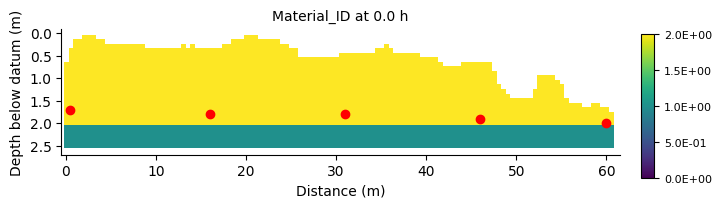

min value for Total_Fe++ [M]: 0.000E+00
max value for Total_Fe++ [M]: 2.763E-04


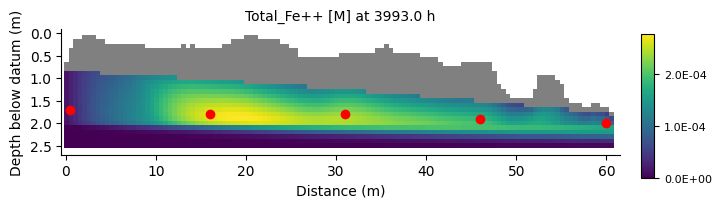

min value for Total_SO4-- [M]: 0.000E+00
max value for Total_SO4-- [M]: 5.090E-04


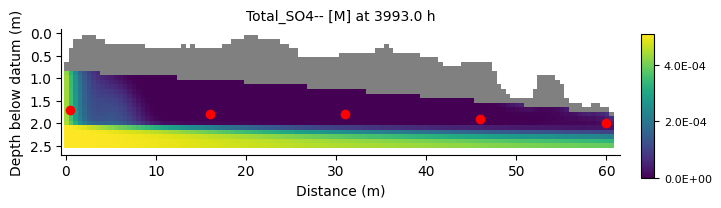

min value for Free_O2(aq) [M]: 0.000E+00
max value for Free_O2(aq) [M]: 2.704E-05


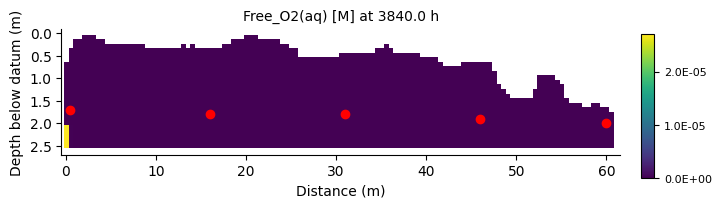

min value for Free_O2(aq) [M]: 0.000E+00
max value for Free_O2(aq) [M]: 7.540E-05


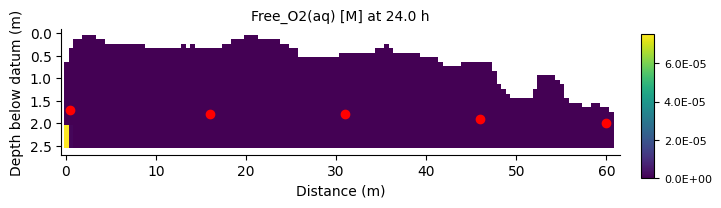

min value for Total_Tracer [M]: 0.000E+00
max value for Total_Tracer [M]: 1.000E-05


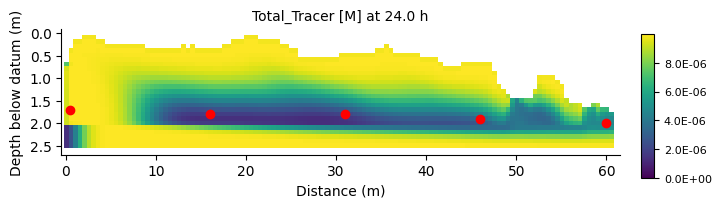

min value for Total_Tracer [M]: 0.000E+00
max value for Total_Tracer [M]: 9.586E-06


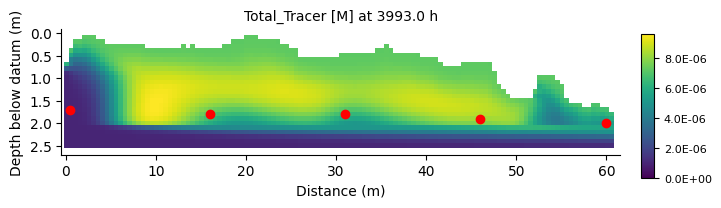

Saved → /Users/christiandewey/Code/dewey-etal_meanders/calibration/run_manual_cal010/manual_cal010_trans_timeseries.png


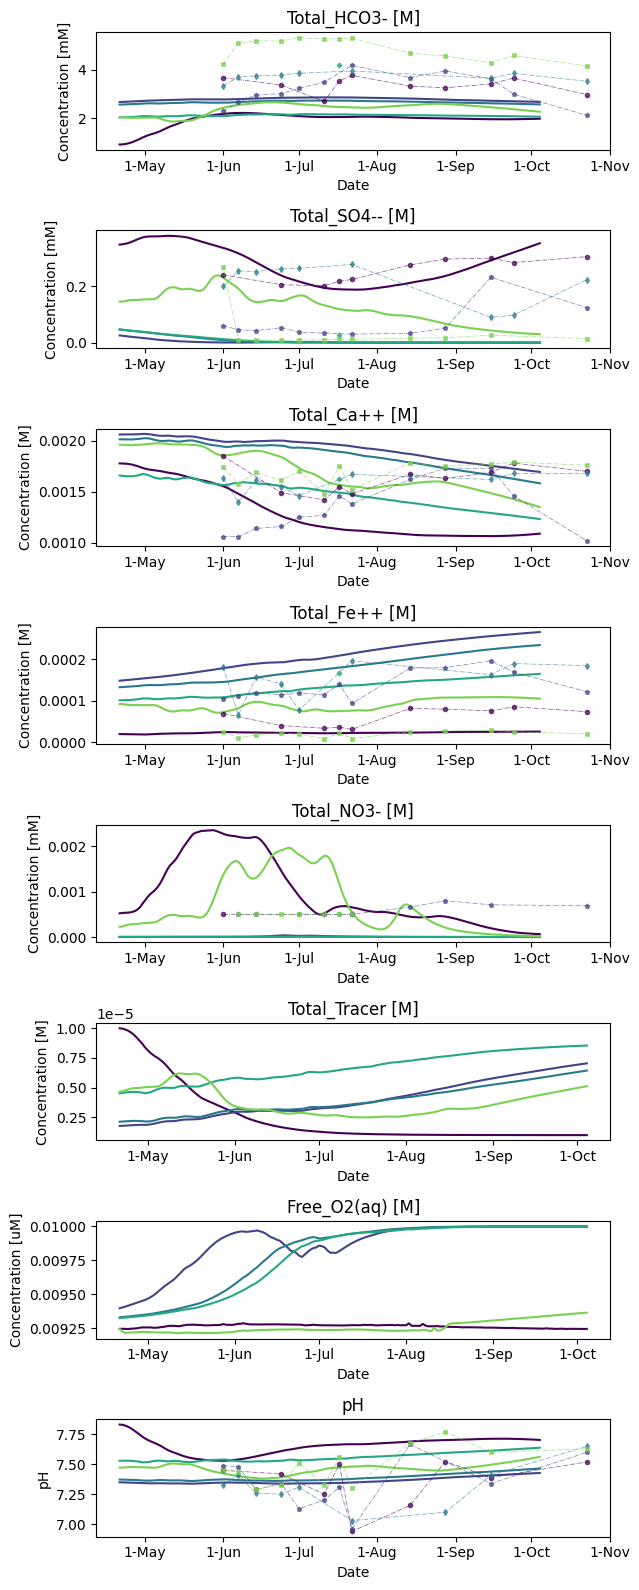

In [3]:
trans_p = PflotranProcessor(h5_path=Path(RUN_PATH,TRANS_FILE), 
    meander='MC',
    perpendicular_axis='x')

trans_p.get_cells()

times = trans_p.times
depths, distances = get_depths_dists('mcp')
locs = [(i,d) for i, d in zip(distances,depths)]

trans_p.get_material_ids(locs=locs)

trans_p.plot_at_time(component=components[3],time_t=times[-1],locs=locs,show_unsat=False)
trans_p.plot_at_time(component=components[1],time_t=times[-1],locs=locs,show_unsat=False)
trans_p.plot_at_time(component=components[6],time_t=times[-8],locs=locs,show_unsat=True)
trans_p.plot_at_time(component=components[6],time_t=times[1],locs=locs,show_unsat=True)
trans_p.plot_at_time(component='Total_Tracer [M]',time_t=times[1],locs=locs,show_unsat=True)
trans_p.plot_at_time(component='Total_Tracer [M]',time_t=times[-1],locs=locs,show_unsat=True)

fig, axs = plt.subplots(len(components),1, figsize= (6.5,16))
startdate = np.datetime64('2019-04-21')
for component, ax in zip(components, axs):
    trans_p.plot_component_histories(component_name=component, startdate=startdate, ax=ax, chem_obs=chem_obs)
    ax.set_title(component)
fig.tight_layout()
fig.savefig(Path(RUN_PATH, f'{RUN_ID}_trans_timeseries.png'), dpi=200, bbox_inches='tight')
print(f"Saved → {Path(RUN_PATH, f'{RUN_ID}_trans_timeseries.png')}")

In [4]:
"""
Log a manual tuning run. Extracts parameter values from the PFLOTRAN
input file, computes per-species objective function from HDF5 output,
appends one row to tuning_log.csv.

"""


import re, csv
import numpy as np
from pathlib import Path
from datetime import datetime

# ── grid / time ──────────────────────────────────────────────
NY, DY, DZ = 122, 0.5, 0.10
T0 = datetime(2019, 4, 21)  # simulation t=0

MEANDER_CONFIG = {
    'MC': {
        'startdate': np.datetime64('2019-04-21'),
        'perpendicular_axis': 'x',
        'obs_file': '/Users/christiandewey/Code/dewey-etal_meanders/data/observational/porewater/mc_2019_porewater.csv',
    },
}
# ── observations: (point_id, y, z, date, DIC, Fe, pH, Ca) ───
n = np.nan
OBS = [
    ('1D', 0.5,1.7, '2019-06-01', 3.67e-3, 6.91e-5, 7.45, 1.85e-3),
    ('1D', 0.5,1.7, '2019-06-24', 3.36e-3, 4.00e-5, 7.42, 1.49e-3),
    ('1D', 0.5,1.7, '2019-07-11', 2.69e-3, 3.35e-5, 7.25, 1.42e-3),
    ('1D', 0.5,1.7, '2019-07-17', 3.54e-3, 3.62e-5, 7.50, 1.55e-3),
    ('1D', 0.5,1.7, '2019-07-22', 3.48e-3, 3.62e-5, 7.41, 1.55e-3),
    ('1D', 0.5,1.7, '2019-08-14', 3.05e-3, 3.84e-5, 7.38, 1.43e-3),
    ('1D', 0.5,1.7, '2019-08-28', 3.17e-3, 2.83e-5, 7.33, 1.43e-3),
    ('1D', 0.5,1.7, '2019-09-15', 2.85e-3, 1.97e-4, 7.26, 1.41e-3),
    ('1D', 0.5,1.7, '2019-09-24', 2.29e-3, 5.89e-5,    n, 1.22e-3),
    ('2D',16.0,2.0, '2019-06-01', 4.69e-3, 1.36e-4, 7.06, 1.66e-3),
    ('2D',16.0,2.0, '2019-06-07', 5.13e-3, 1.74e-4, 6.94, 1.77e-3),
    ('2D',16.0,2.0, '2019-06-14', 5.31e-3, 1.25e-4, 7.03, 1.86e-3),
    ('2D',16.0,2.0, '2019-06-24', 4.34e-3, 1.30e-4, 7.09, 1.55e-3),
    ('2D',16.0,2.0, '2019-07-01', 3.98e-3, 1.59e-4, 7.10, 1.50e-3),
    ('2D',16.0,2.0, '2019-07-11', 3.59e-3, 7.88e-6, 7.13, 1.43e-3),
    ('2D',16.0,2.0, '2019-07-17',       n, 1.22e-4, 7.16, 1.48e-3),
    ('2D',16.0,2.0, '2019-07-22', 3.42e-3, 1.16e-4, 7.15, 1.39e-3),
    ('2D',16.0,2.0, '2019-08-14', 3.63e-3, 1.48e-4, 7.02, 1.31e-3),
    ('2D',16.0,2.0, '2019-08-28', 3.45e-3, 9.19e-5,    n, 1.41e-3),
    ('2D',16.0,2.0, '2019-09-15', 3.25e-3, 1.77e-4, 7.06, 1.26e-3),
    ('2D',16.0,2.0, '2019-09-24', 3.34e-3, 1.28e-4,    n, 1.33e-3),
    ('3D',31.0,2.1, '2019-06-01', 4.46e-3, 1.21e-4, 7.14, 1.50e-3),
    ('3D',31.0,2.1, '2019-06-07', 4.78e-3, 1.52e-4, 7.04, 1.63e-3),
    ('3D',31.0,2.1, '2019-06-14', 4.49e-3, 9.96e-5, 7.12, 1.58e-3),
    ('3D',31.0,2.1, '2019-06-24', 4.13e-3, 1.28e-4, 7.12, 1.47e-3),
    ('3D',31.0,2.1, '2019-07-01', 4.19e-3, 1.02e-4, 7.18, 1.48e-3),
    ('3D',31.0,2.1, '2019-07-22', 3.59e-3, 1.21e-4, 7.19, 1.41e-3),
    ('3D',31.0,2.1, '2019-09-15', 3.02e-3, 1.67e-4, 7.14, 1.26e-3),
    ('3D',31.0,2.1, '2019-09-24', 2.86e-3, 1.38e-4,    n, 1.06e-3),
    ('4D',46.0,2.4, '2019-07-17', 3.71e-3, 1.08e-4,    n, 1.31e-3),
    ('5D',60.0,2.5, '2019-06-01', 4.37e-3, 6.20e-5, 7.27, 1.50e-3),
    ('5D',60.0,2.5, '2019-06-07', 4.19e-3, 6.26e-5, 7.35, 1.46e-3),
    ('5D',60.0,2.5, '2019-06-14', 3.97e-3, 6.81e-5, 7.29, 1.48e-3),
    ('5D',60.0,2.5, '2019-06-24', 3.61e-3, 5.67e-5, 7.34, 1.35e-3),
    ('5D',60.0,2.5, '2019-07-01', 3.70e-3, 6.30e-5, 7.40, 1.39e-3),
    ('5D',60.0,2.5, '2019-07-11', 3.58e-3, 7.35e-5, 7.38, 1.40e-3),
    ('5D',60.0,2.5, '2019-07-17', 3.46e-3, 6.34e-5, 7.39, 1.31e-3),
    ('5D',60.0,2.5, '2019-07-22', 3.37e-3, 5.76e-5, 7.37, 1.28e-3),
    ('5D',60.0,2.5, '2019-08-14', 3.69e-3, 7.27e-5, 7.04, 1.28e-3),
    ('5D',60.0,2.5, '2019-08-28', 3.23e-3, 6.66e-5, 7.77, 1.27e-3),
    ('5D',60.0,2.5, '2019-09-15', 3.00e-3, 1.03e-4, 7.43, 1.22e-3),
    ('5D',60.0,2.5, '2019-09-24', 2.85e-3, 7.40e-5,    n, 1.18e-3),
]

# ── parameter regex patterns (searched with re.DOTALL) ───────
PARAM_PATTERNS = {
    'aero_rate':   r'SOC\(aq\).*?O2\(aq\).*?RATE_CONSTANT\s+(\S+)',
    'aero_k_o2':   r'SOC\(aq\).*?O2\(aq\).*?HALF_SATURATION_CONSTANT\s+(\S+)',
    'denit_rmax':   r'JINBETHKE_NITRATE_ACETATE\s+RMAX\s+(\S+)',
    'denit_k_acc':  r'JINBETHKE_NITRATE_ACETATE.*?K_ACCEPTOR\s+(\S+)',
    'fh_rmax':      r'JINBETHKE_FERRIHYDRITE_ACETATE\s+RMAX\s+(\S+)',
    'fh_k_donor':   r'JINBETHKE_FERRIHYDRITE_ACETATE.*?K_DONOR\s+(\S+)',
    'msr_k_donor':  r'JINBETHKE_SULFATE_ACETATE.*?K_DONOR\s+(\S+)',
    'root_resp':    r'Root_Respiration\s+DISSOLUTION_RATE_CONSTANT\s+(\S+)',
}

def fortran_float(s):
    return float(s.strip().lower().replace('d', 'e'))

def fmt_param(v):
    """Format a parameter value to 3 significant figures in scientific notation."""
    if isinstance(v, (int, float, np.floating)) and not np.isnan(v):
        return f"{v:.2e}"
    return v

def fmt_metric(v):
    """Format a metric value to 3 significant figures."""
    if isinstance(v, (int, float, np.floating)) and not np.isnan(v):
        return f"{v:.3g}"
    return v

def extract_params(infile):
    text = open(infile).read()
    vals = {}
    for name, pattern in PARAM_PATTERNS.items():
        m = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        vals[name] = fortran_float(m.group(1)) if m else np.nan
    return vals

def check_repeat(log_path, param_keys, formatted_params):
    """Check if formatted param values already exist in the log."""
    if not log_path.exists():
        return False
    with open(log_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if all(row.get(k) == str(formatted_params[k]) for k in param_keys):
                return True
    return False

def compute_metrics(meander='MC'):
    """
    Use PflotranProcessor to compute KGE, NSE, RMSE per component.
    Returns dict with per-component and summary metrics.
    """
    cfg = MEANDER_CONFIG[meander]

    # find main HDF5 output
    h5file = Path(RUN_PATH,TRANS_FILE)


    # load observations
    chem_obs = pd.read_csv(cfg['obs_file'], parse_dates=['Date'])

    # initialize processor
    proc = PflotranProcessor(
        h5_path=str(h5file),
        meander=meander,
        perpendicular_axis=cfg['perpendicular_axis'],
    )

    # calculate goodness-of-fit
    results = proc.calculate_kge(
        startdate=cfg['startdate'],
        chem_obs=chem_obs,
    )

    # extract per-component stats from summary DataFrame
    summary = results['summary']
    metrics = {}
    for _, row in summary.iterrows():
        comp = row['Obs']  # observation column name (TIC, Fe, pH, Ca, etc.)
        metrics[f'KGE_{comp}']  = row['KGE']
        metrics[f'NSE_{comp}']  = row['NSE']
        metrics[f'RMSE_{comp}'] = row['RMSE']
        metrics[f'n_{comp}']    = row['n']

    # overall mean KGE across components
    metrics['KGE_mean'] = summary['KGE'].mean()

    return metrics


# extract parameters
params = extract_params(Path(RUN_PATH,TRANS_FILE).with_suffix('.in'))

# compute metrics via PflotranProcessor
metrics = compute_metrics(meander='MC')

# print summary
print(f"\n{'─'*55}")
print(f"Run: {RUN_ID}  {NOTE}")
print(f"{'─'*55}")
print("Parameters:")
for k, v in params.items():
    print(f"  {k:<16s} {fmt_param(v)}")
print("\nMetrics (via PflotranProcessor):")
for k, v in sorted(metrics.items()):
    print(f"  {k:<16s} {fmt_metric(v)}")
print(f"{'─'*55}")

# append to CSV
log = Path(Path(RUN_PATH).parent / 'tuning_log.csv')
param_keys = list(PARAM_PATTERNS.keys())
metric_keys = sorted(metrics.keys())
fields = ['timestamp', 'run', 'meander', 'note'] + param_keys + metric_keys

write_hdr = not log.exists()

formatted_params = {k: fmt_param(v) for k, v in params.items()}

is_repeat = check_repeat(log, param_keys, formatted_params)
note = f"{NOTE} [REPEAT]" if is_repeat else NOTE
if is_repeat:
    print("⚠ Parameters match an existing entry — flagged as REPEAT")

row = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'run': RUN_ID,
    'meander': 'MC',
    'note': note,
}
row.update(formatted_params)
row.update({k: fmt_metric(v) for k, v in metrics.items()})

with open(log, 'a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields, extrasaction='ignore')
    if write_hdr:
        w.writeheader()
    w.writerow(row)

print(f"→ {log}")


KGE Summary - 25 components with observations
Component                 Obs               KGE      NSE       RMSE      r      α      β     n
--------------------------------------------------------------------------------
Total_Fe++ [M]            Fe              0.443   -0.074   6.42e-05  0.749  1.232  1.440    42
Free_Fe++ [M]             Fe              0.455    0.377   4.89e-05  0.755  0.606  0.714    42
Total_SO4-- [M]           SO4             0.313   -0.301   1.27e-04  0.366  0.954  0.739    39
Free_SO4-- [M]            SO4             0.279   -0.242   1.24e-04  0.377  0.863  0.664    39
Total_Ca++ [M]            Ca             -0.521   -3.979   4.49e-04 -0.419  1.545  1.071    42
Free_Ca++ [M]             Ca             -0.521   -3.757   4.39e-04 -0.423  1.534  1.042    42
Total_Mg++ [M]            Mg             -0.596  -25.348   3.05e-04 -0.249  0.330  0.266    42
Free_Mg++ [M]             Mg             -0.609  -25.900   3.08e-04 -0.263  0.334  0.258    42
Total_Na+ [M]    


--- Validation Stats: Total_HCO3- [M] ---
  R²    = 0.002
  NSE   = -3.825
  KGE   = -0.238
  RMSE  = 1.72e+00
  Bias  = -1.52e+00
  Slope = 0.015
  n     = 41

--- Validation Stats: Total_Fe++ [M] ---
  R²    = 0.571
  NSE   = 0.444
  KGE   = 0.685
  RMSE  = 4.62e-02
  Bias  = 1.76e-02
  Slope = 0.734
  n     = 42

--- Validation Stats: pH ---
  R²    = 0.006
  NSE   = -0.596
  KGE   = 0.001
  RMSE  = 2.35e-01
  Bias  = 1.05e-01
  Slope = 0.048
  n     = 37

--- Validation Stats: Total_Ca++ [M] ---
  R²    = 0.132
  NSE   = -5.283
  KGE   = -0.563
  RMSE  = 5.04e-01
  Bias  = 1.94e-01
  Slope = -0.637
  n     = 42

--- Validation Stats: Total_SO4-- [M] ---
  R²    = 0.120
  NSE   = -0.116
  KGE   = 0.324
  RMSE  = 1.18e-01
  Bias  = 5.05e-03
  Slope = 0.288
  n     = 39

--- Validation Stats: Total_Mg++ [M] ---
  R²    = 0.051
  NSE   = -24.446
  KGE   = -0.551
  RMSE  = 3.00e-01
  Bias  = -2.92e-01
  Slope = -0.085
  n     = 42
Saved → /Users/christiandewey/Code/dewey-etal_meanders/

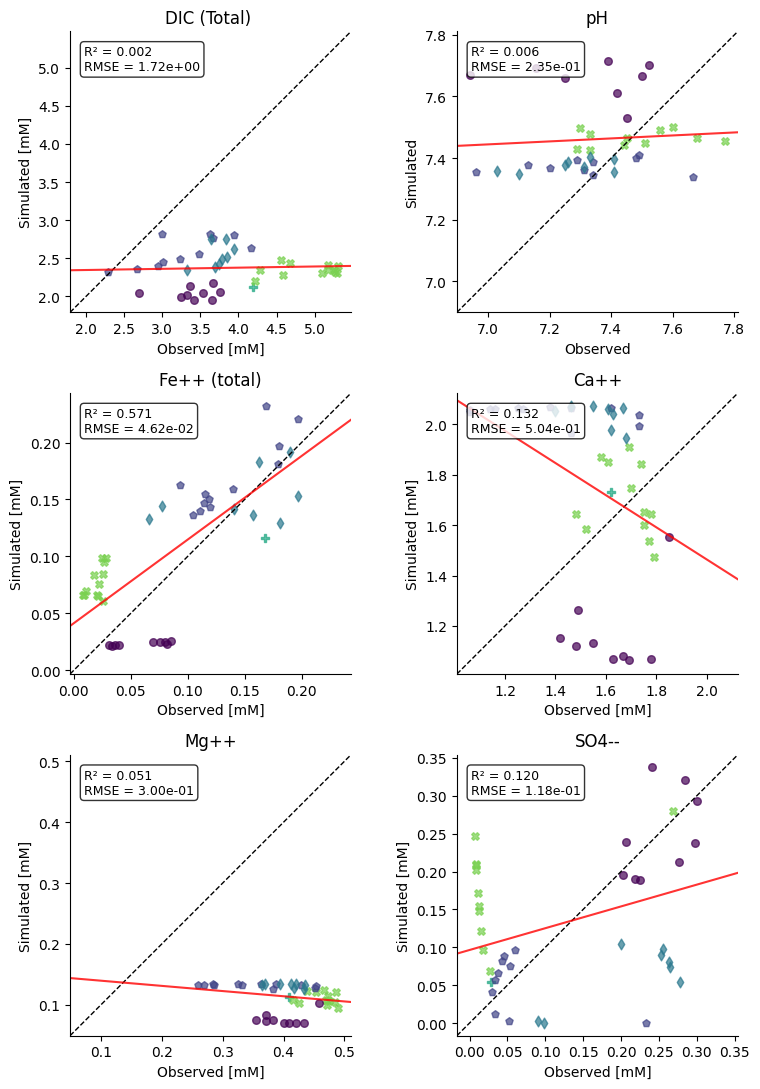

In [11]:
#####
## 1 to 1 plots for transient simulation
#####

fig, axs = plt.subplots(3,2,figsize=(8, 11))

ax = axs[0,0]
ax = trans_p.plot_validation(
    'Total_HCO3- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax, 
    show_legend=False
)
ax.set_title('DIC (Total) ')

ax = axs[1,0]
ax = trans_p.plot_validation(
    'Total_Fe++ [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('Fe++ (total)')

ax = axs[0,1]
ax = trans_p.plot_validation(
    'pH',
    startdate=startdate,
    chem_obs=chem_obs,
    ax=ax,
    show_legend=False
)
ax.set_title('pH')

ax = axs[1,1]
ax = trans_p.plot_validation(
    'Total_Ca++ [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('Ca++')

ax = axs[2,1]
ax = trans_p.plot_validation(
    'Total_SO4-- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('SO4--')

ax = axs[2,0]
ax = trans_p.plot_validation(
    'Total_Mg++ [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('Mg++')

sns.despine()

fig.tight_layout()
fig.savefig(Path(RUN_PATH, f'{RUN_ID}_validation.png'), dpi=200, bbox_inches='tight')
print(f"Saved → {Path(RUN_PATH, f'{RUN_ID}_validation.png')}")